In [10]:
# ==================
# Imports and Setup
# =================

# libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Soil Theme Palette
PALETTE = {
    "clay_brown": "#8B5A2B",
    "deep_brown": "#5A3E2B",
    "green": "#2E7D32",
    "blue": "#1E88E5",
    "red": "#8B0000",
    "orange": "#F57C00",
    "yellow": "#FBC02D",
    "sand": "#F5E6C4",
    "charcoal": "#2B2B2B"
}

# Global style
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.facecolor": PALETTE["sand"],
    "figure.facecolor": PALETTE["sand"],
    "axes.edgecolor": PALETTE["charcoal"],
    "axes.labelcolor": PALETTE["charcoal"],
    "xtick.color": PALETTE["charcoal"],
    "ytick.color": PALETTE["charcoal"],
    "text.color": PALETTE["charcoal"],
    "axes.titleweight": "bold"
})

In [12]:
# load data
df = pd.read_csv("clay_clean.csv")
df.head()

,longitude,latitude,profile_id,layer_id,profile_code,layer_name,upper_depth,lower_depth,organic_surface,value,...,dataset_id,country_name,positional_uncertainty,region,continent,date,licence,depth_mid,depth_thickness,depth_category
0,26.09778,-30.145280,590355,146621,ZA SOTER_6076,B,30,90,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-3-1,Attribution-NonCommercial 3.0 International (C...,60.0,60,Deep
1,30.02350,-27.592199,574310,2910210,icr048468,NaN,0,20,0,NaN,...,AF-AfSIS-I,South Africa,Circa 100 m,Southern Africa,Africa,????-??-??,"Attribution 4.0 International (CC BY 4.0), htt...",10.0,20,Surface
2,26.04667,-28.983330,590352,146613,ZA SOTER_104,C,90,100,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-5-1,Attribution-NonCommercial 3.0 International (C...,95.0,10,Deep
3,29.87667,-27.588330,590646,147482,ZA SOTER_4394,B,20,80,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1978-10-1,Attribution-NonCommercial 3.0 International (C...,50.0,60,Mid
4,29.30556,-26.208330,590604,147358,ZA SOTER_1790,A,0,45,0,NaN,...,AF-AfSP,South Africa,Circa 100 m,Southern Africa,Africa,1973-8-1,Attribution-NonCommercial 3.0 International (C...,22.5,45,Mid


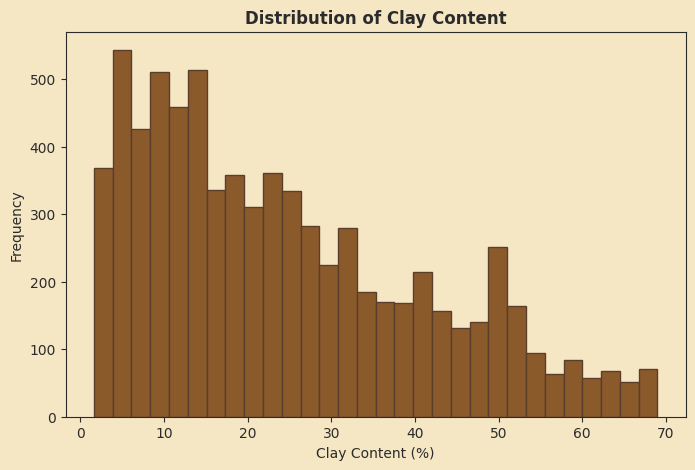

In [22]:
# Distribution of Clay

plt.hist(
    df['value_avg'],
    bins=30,
    color=PALETTE["clay_brown"],
    edgecolor=PALETTE["deep_brown"]
)

plt.title("Distribution of Clay Content")
plt.xlabel("Clay Content (%)")
plt.ylabel("Frequency")
plt.show()

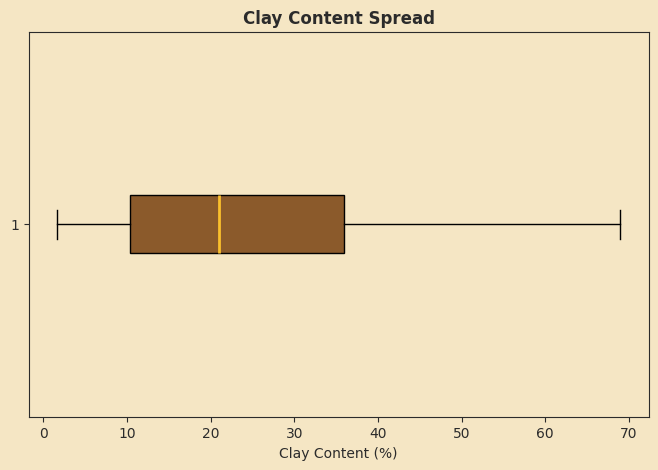

In [20]:
# Content Spread

plt.boxplot(
    df['value_avg'],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor=PALETTE["clay_brown"]),
    medianprops=dict(color=PALETTE["yellow"], linewidth=2)
)

plt.title("Clay Content Spread")
plt.xlabel("Clay Content (%)")
plt.show()

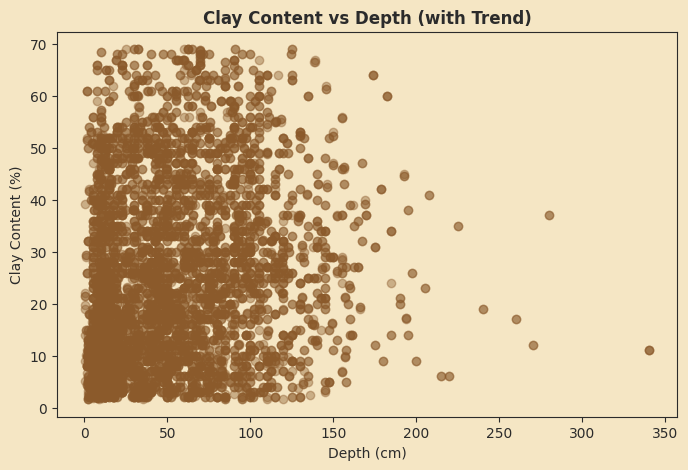

C:\Users\rfull\AppData\Local\Temp\ipykernel_1804\2574645141.py:40: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


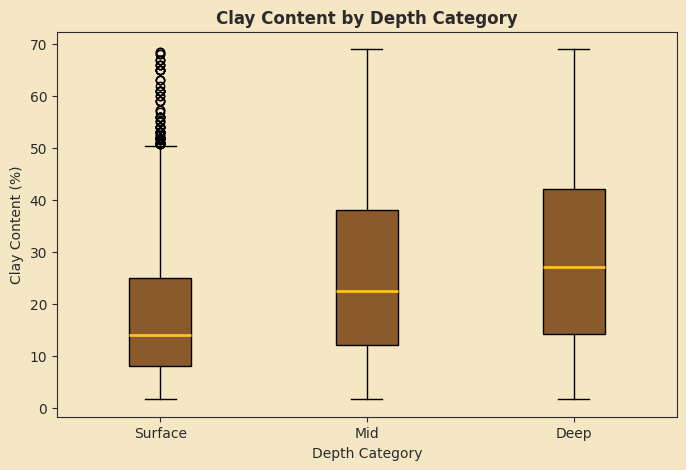

In [26]:
# ================
# Clay vs. Depth
# ================

# Scatter Plot
plt.scatter(
    df['depth_mid'],
    df['value_avg'],
    alpha=0.4,
    color=PALETTE["clay_brown"]
)

# Added Trend Line
z = np.polyfit(df['depth_mid'], df['value'], 1)
p = np.poly1d(z)

plt.plot(
    df['depth_mid'],
    p(df['depth_mid']),
    color=PALETTE["red"],
    linewidth=2
)

plt.title("Clay Content vs Depth (with Trend)")
plt.xlabel("Depth (cm)")
plt.ylabel("Clay Content (%)")
plt.show()

# --------------------------
# Add Depth Categoreis
# --------------------------

categories = ["Surface", "Mid", "Deep"]

data = [
    df[df['depth_category'] == cat]['value_avg']
    for cat in categories
]

plt.boxplot(
    data,
    patch_artist=True,
    labels=categories,
    boxprops=dict(facecolor=PALETTE["clay_brown"]),
    medianprops=dict(color=PALETTE["yellow"], linewidth=2)
)

plt.title("Clay Content by Depth Category")
plt.xlabel("Depth Category")
plt.ylabel("Clay Content (%)")
plt.show()

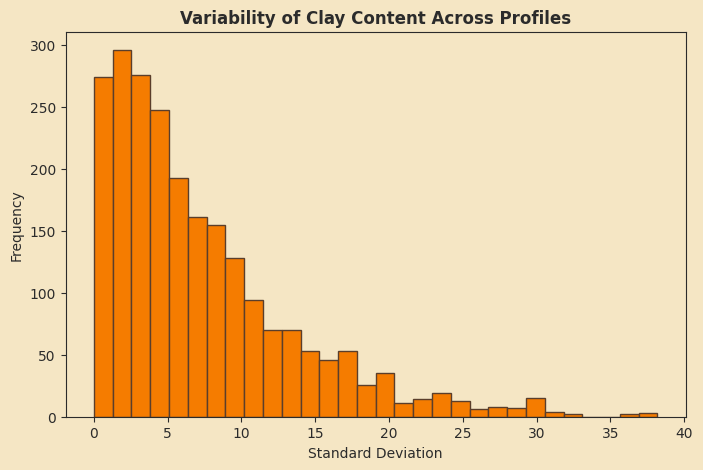

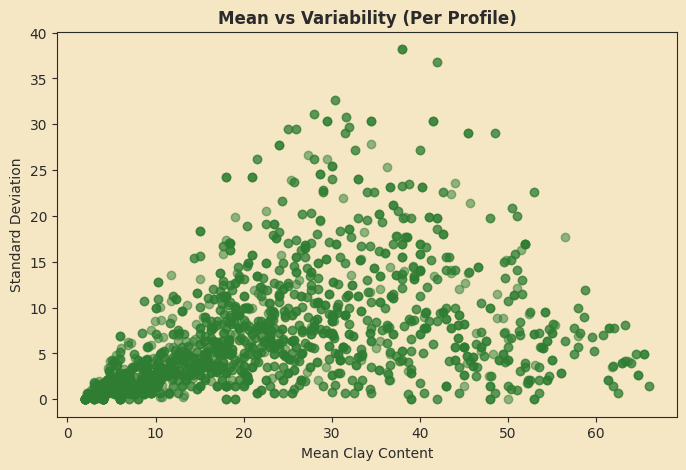

In [32]:
# ============================
# Profile Level Variability
# ============================

# Compute Variability
profile_stats = df.groupby('profile_id')['value_avg'].agg(['mean', 'std']).reset_index()

# Histogram of Variability
plt.hist(
    profile_stats['std'].dropna(),
    bins=30,
    color=PALETTE["orange"],
    edgecolor=PALETTE["deep_brown"]
)

plt.title("Variability of Clay Content Across Profiles")
plt.xlabel("Standard Deviation")
plt.ylabel("Frequency")
plt.show()

# Mean vs. Variability
plt.scatter(
    profile_stats['mean'],
    profile_stats['std'],
    alpha=0.5,
    color=PALETTE["green"]
)

plt.title("Mean vs Variability (Per Profile)")
plt.xlabel("Mean Clay Content")
plt.ylabel("Standard Deviation")
plt.show()

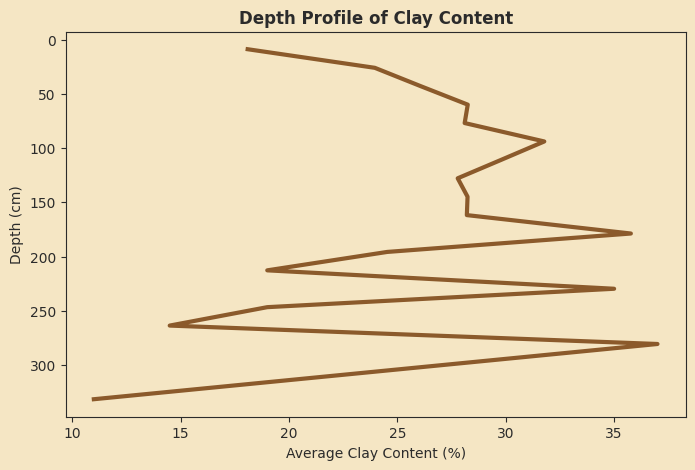

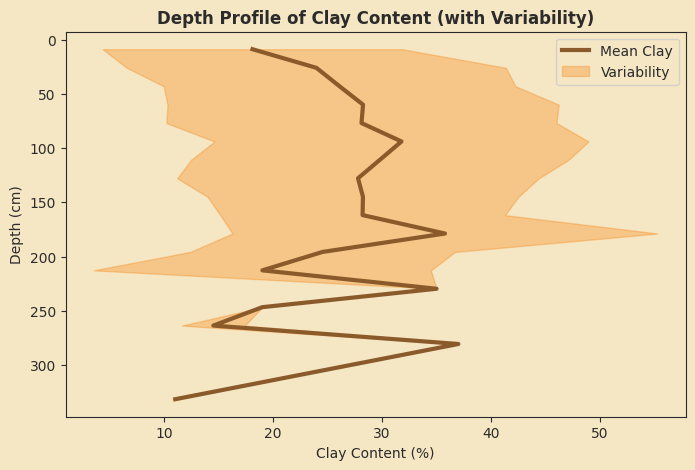

In [36]:
# --------------------
# Profile Depth Curve
# --------------------

# Create depth bins (every 5 cm — adjust if needed)
df['depth_bin'] = pd.cut(df['depth_mid'], bins=20)

# Compute mean clay per bin
depth_profile = df.groupby('depth_bin')['value_avg'].mean().reset_index()

# Extract bin midpoints for plotting
depth_profile['depth_mid_bin'] = depth_profile['depth_bin'].apply(lambda x: x.mid)

# Confidence Curve
plt.plot(
    depth_profile['value_avg'],
    depth_profile['depth_mid_bin'],
    color=PALETTE["clay_brown"],
    linewidth=3
)

# Invert y-axis (depth increases downward)
plt.gca().invert_yaxis()

plt.title("Depth Profile of Clay Content")
plt.xlabel("Average Clay Content (%)")
plt.ylabel("Depth (cm)")
plt.show()

# Add variability (std per bin)
depth_stats = df.groupby('depth_bin')['value_avg'].agg(['mean', 'std']).reset_index()
depth_stats['depth_mid_bin'] = depth_stats['depth_bin'].apply(lambda x: x.mid)

plt.plot(
    depth_stats['mean'],
    depth_stats['depth_mid_bin'],
    color=PALETTE["clay_brown"],
    linewidth=3,
    label="Mean Clay"
)

plt.fill_betweenx(
    depth_stats['depth_mid_bin'],
    depth_stats['mean'] - depth_stats['std'],
    depth_stats['mean'] + depth_stats['std'],
    color=PALETTE["orange"],
    alpha=0.3,
    label="Variability"
)

plt.gca().invert_yaxis()

plt.title("Depth Profile of Clay Content (with Variability)")
plt.xlabel("Clay Content (%)")
plt.ylabel("Depth (cm)")

plt.legend()
plt.show()